Code inspired from here: https://scikit-learn.org/stable/auto_examples/neighbors/plot_lof_novelty_detection.html#sphx-glr-auto-examples-neighbors-plot-lof-novelty-detection-py 

In [215]:
import grewpy
import yaml
import sys
import numpy as np

sys.path.insert(1, '/Users/madalina/Documents/M2TAL/stage/grex/grex2')
import pyximport
pyximport.install()
import grex.data
import grex.utils
import grex.features

path = "/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master"
grewpy.set_config('ud')
corpus = grewpy.Corpus(path)
draft = grewpy.CorpusDraft(corpus)

all_matches = corpus.search(grewpy.Request("pattern{X[upos=ADV]}").without("X[InIdiom=Yes]").without("X[Idiom=Yes]"), clustering_parameter=['X.lemma'])
matches = {}
for key, value in all_matches.items():
    # remove those that have less than 10 occurrences
    if len(value) > 10:
        matches[key] = value

with open("/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/4. occurrences_as_features/patterns_adv_no_idioms.txt") as instream:
    config = yaml.load(instream, Loader=yaml.Loader)

templates = grex.utils.FeaturePredicate.from_config(config["templates"])
feature_predicate = grex.utils.FeaturePredicate.from_config(config["features"], templates=templates)

In [216]:
data = { k : list() for k in matches }
for adv, mts in matches.items():
    for match in mts:
        features = grex.data.extract_features(draft, match, feature_predicate)
        formatted_features = [
            f"{':'.join(k)}={v}" if not isinstance(v, set) else
            f"{':'.join(k)}={val}" for k, v in features.items() for val in (v if isinstance(v, set) else [v])
        ]
        data[adv].append(formatted_features)
unique_adv = sorted(set([k for k in data]))
unique_features = sorted(set([feat for _, matches in data.items() for m in matches for feat in m]))

idx2feature = {i : feat for i, feat in enumerate(unique_features) }
feature2idx = {feat : i for i, feat in idx2feature.items()}
idx2adv = {i : feat for i, feat in enumerate(unique_adv) }
adv2idx = {feat : i for i, feat in idx2adv.items()}

X = np.zeros((len(data.keys()), len(unique_features)))
for adv, samples in data.items():
    n_samples = len(samples)
    for m in samples:
        for feature in m:
            X[adv2idx[adv], feature2idx[feature]] += 1
    X[adv2idx[adv]] = (X[adv2idx[adv]] / n_samples)*100
print(f"{X.shape=}")

X.shape=(123, 327)


In [217]:
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Fit the model for novelty detection
clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
clf.fit(X)

# Predict outliers 
y_pred = clf.fit_predict(X)
n_outliers = np.sum(y_pred == -1)



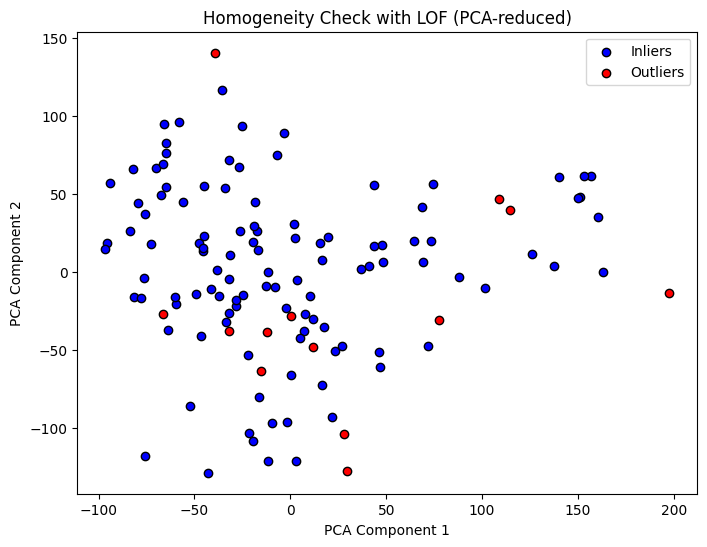

Number of outliers detected: 13/123


In [218]:
# Dimensionality reduction for visualization (optional)
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

# Plot the data in 2D after PCA
plt.figure(figsize=(8, 6))
plt.scatter(
    X_reduced[y_pred == 1, 0], X_reduced[y_pred == 1, 1],
    c="blue", label="Inliers", edgecolors="k"
)
plt.scatter(
    X_reduced[y_pred == -1, 0], X_reduced[y_pred == -1, 1],
    c="red", label="Outliers", edgecolors="k"
)
plt.title("Homogeneity Check with LOF (PCA-reduced)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

print(f"Number of outliers detected: {n_outliers}/{X.shape[0]}")

In [7]:
# if y pred is -1 print the adv
for i, pred in enumerate(y_pred):
    if pred == -1:
        print(idx2adv[i])

afin
autrement
avant
comment
environ
ne
pourquoi
que
soit
spécialement
tard
vis-à-vis
vivement


In [81]:
from sklearn.manifold import TSNE
import plotly.graph_objects as go

# Dimensionality reduction using t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_reduced = tsne.fit_transform(X)

# Prepare data for Plotly visualization
data = {
    "Component 1": X_reduced[:, 0],
    "Component 2": X_reduced[:, 1],
    "Adverb": [idx2adv[i] for i in range(X.shape[0])],
    "Outlier": ["Outlier" if pred == -1 else "Inlier" for pred in y_pred],
}

# Create a scatter plot with Plotly
fig = go.Figure()

# Add scatter points
fig.add_trace(go.Scatter(
    x=data["Component 1"],
    y=data["Component 2"],
    mode='markers',
    marker=dict(size=10, color=["red" if o == "Outlier" else "blue" for o in data["Outlier"]]),
    text=data["Adverb"],  # Adverbs for hover
    customdata=data["Outlier"],  # Inlier/Outlier status for hover
    hovertemplate="Adverb: %{text}<br>Status: %{customdata}<extra></extra>"
))

# Update layout
fig.update_layout(
    title="t-SNE Visualization of Adverbs with LOF Outlier Detection",
    xaxis_title="t-SNE Component 1",
    yaxis_title="t-SNE Component 2",
    width=800,
    height=600
)

# Show the plot
fig.show()

print(f"Number of outliers detected: {n_outliers}/{X.shape[0]}")

Number of outliers detected: 13/123


In [13]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
import numpy as np

# Randomly split the data into 80% train and 20% test, keeping track of indices
indices = np.arange(X.shape[0])  # Create an array of indices
X_train, X_test, train_idx, test_idx = train_test_split(X, indices, test_size=0.2, random_state=42)

# Fit the model for novelty detection on the training set
clf = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.1)
clf.fit(X_train)

# Predict on the test set
y_pred = clf.predict(X_test)
n_outliers = np.sum(y_pred == -1)

# Map test indices to adverbs and identify novel adverbs
novel_adverbs = [idx2adv[test_idx[i]] for i, pred in enumerate(y_pred) if pred == -1]

print(f"Number of novel points detected: {n_outliers}/{X_test.shape[0]}")
print("Novel adverbs detected:")
print(novel_adverbs)

Number of novel points detected: 3/25
Novel adverbs detected:
['vis-à-vis', 'contrairement', 'comment']


# What if we did this for all categories?

In [219]:
import grewpy
import yaml
import sys
import numpy as np

sys.path.insert(1, '/Users/madalina/Documents/M2TAL/stage/grex/grex2')
import pyximport
pyximport.install()
import grex.data
import grex.utils
import grex.features

# path = "/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master"
# grewpy.set_config('ud')
path = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/input/SUD_French-GSD-r2.15"
grewpy.set_config('sud')
corpus = grewpy.Corpus(path)
draft = grewpy.CorpusDraft(corpus)

all_matches = corpus.search(grewpy.Request("pattern{X[upos<>PUNCT]}").without("X[InIdiom=Yes]").without("X[Idiom=Yes]").without("X[InTitle=Yes]").without("X[Title=Yes]").without("X[Scrap=Yes]").without("X[Foreign]").without("X[Lang]").without("X-[fixed]->Y").without("Y-[flat:name]->X").without("Y-[goeswith]->X") , clustering_parameter=['X.lemma'])
matches = {}
for key, value in all_matches.items():
    # remove those that have less than 10 occurrences
    if len(value) > 10:
        matches[key] = value
import json 
# Create a dictionary to map sent_id to sentences for quick lookup
sent_id_to_sentence = {draft[i].meta['sent_id']: draft[i].features for i in range(len(draft))}

match_upos = {}
for key, value in matches.items():
    for m in value:
        match_sent_id = m['sent_id']
        match_node_index = str(m['matching']['nodes']['X'])
        if match_sent_id in sent_id_to_sentence:
            current_sentence_features = sent_id_to_sentence[match_sent_id]
            if match_node_index in current_sentence_features.keys():
                current_token_features = current_sentence_features[match_node_index]
                if 'ExtPos' in current_token_features:
                    match_upos.setdefault((key, current_token_features['ExtPos']), []).append(m)
                else:
                    match_upos.setdefault((key, current_token_features['upos']), []).append(m)
new_match_upos = {}
for key, value in match_upos.items():
    if len(value) > 10:
        new_match_upos[key] = value
match_upos = new_match_upos

for key, value in match_upos.items():
    print(key, len(value))


('€', 'NOUN') 45
('œuvrer', 'VERB') 12
('œuvre', 'NOUN') 115
('œuf', 'NOUN') 19
('œil', 'NOUN') 33
('île', 'NOUN') 124
('être', 'AUX') 9438
('être', 'VERB') 149
('évêque', 'NOUN') 45
('événement', 'NOUN') 50
('évènement', 'NOUN') 20
('évoquer', 'VERB') 29
('évolution', 'NOUN') 39
('évoluer', 'VERB') 65
('éviter', 'VERB') 42
('évidence', 'NOUN') 13
('éventuellement', 'ADV') 12
('éventuel', 'ADJ') 13
('évaluer', 'VERB') 11
('été', 'NOUN') 57
('étudier', 'VERB') 45
('étudiant', 'NOUN') 23
('étude', 'NOUN') 99
('étranger', 'ADJ') 45
('étranger', 'NOUN') 16
('étrange', 'ADJ') 20
('étoile', 'NOUN') 42
('étendre', 'VERB') 36
('état', 'NOUN') 149
('étape', 'NOUN') 28
('étang', 'NOUN') 11
('étage', 'NOUN') 20
('établissement', 'NOUN') 43
('établir', 'VERB') 75
('équiper', 'VERB') 22
('équipement', 'NOUN') 21
('équipe', 'NOUN') 233
('équipage', 'NOUN') 11
('épreuve', 'NOUN') 41
('épouser', 'VERB') 27
('épouse', 'NOUN') 32
('époque', 'NOUN') 100
('épisode', 'NOUN') 49
('énorme', 'ADJ') 11
('énerg

In [220]:
with open("../3. probability_matrix/patterns_all_nodes.txt") as instream:
    config = yaml.load(instream, Loader=yaml.Loader)

templates = grex.utils.FeaturePredicate.from_config(config["templates"])
feature_predicate = grex.utils.FeaturePredicate.from_config(config["features"], templates=templates)

data = { k : list() for k in match_upos }
for adv, mts in match_upos.items():
    for match in mts:
        features = grex.data.extract_features(draft, match, feature_predicate)
        formatted_features = [
            f"{':'.join(k)}={v}" if not isinstance(v, set) else
            f"{':'.join(k)}={val}" for k, v in features.items() for val in (v if isinstance(v, set) else [v])
        ]
        data[adv].append(formatted_features)

unique_lemma = sorted(set([k for k in data]))
unique_features = sorted(set([feat for _, match_upos in data.items() for m in match_upos for feat in m]))

idx2feature = {i : feat for i, feat in enumerate(unique_features) }
feature2idx = {feat : i for i, feat in idx2feature.items()}
idx2adv = {i : feat for i, feat in enumerate(unique_lemma) }
adv2idx = {feat : i for i, feat in idx2adv.items()}

In [84]:
print(unique_lemma)

[('$', 'NOUN'), ('%', 'NOUN'), ('&', 'CCONJ'), ('/', 'ADP'), ('/', 'CCONJ'), ('0', 'NUM'), ('1', 'NUM'), ('10', 'NUM'), ('100', 'NUM'), ('11', 'NUM'), ('12', 'NUM'), ('13', 'NUM'), ('14', 'NUM'), ('15', 'NUM'), ('150', 'NUM'), ('16', 'NUM'), ('17', 'NUM'), ('18', 'NUM'), ('1868', 'NUM'), ('19', 'NUM'), ('1905', 'NUM'), ('1908', 'NUM'), ('1909', 'NUM'), ('1911', 'NUM'), ('1914', 'NUM'), ('1918', 'NUM'), ('1920', 'NUM'), ('1922', 'NUM'), ('1925', 'NUM'), ('1926', 'NUM'), ('1930', 'NUM'), ('1931', 'NUM'), ('1932', 'NUM'), ('1933', 'NUM'), ('1934', 'NUM'), ('1935', 'NUM'), ('1936', 'NUM'), ('1937', 'NUM'), ('1938', 'NUM'), ('1939', 'NUM'), ('1940', 'NUM'), ('1941', 'NUM'), ('1942', 'NUM'), ('1943', 'NUM'), ('1944', 'NUM'), ('1945', 'NUM'), ('1946', 'NUM'), ('1947', 'NUM'), ('1948', 'NUM'), ('1949', 'NUM'), ('1950', 'NUM'), ('1952', 'NUM'), ('1953', 'NUM'), ('1954', 'NUM'), ('1955', 'NUM'), ('1956', 'NUM'), ('1957', 'NUM'), ('1958', 'NUM'), ('1959', 'NUM'), ('1960', 'NUM'), ('1961', 'NUM'),

In [221]:
X = np.zeros((len(data.keys()), len(unique_features)))
for adv, samples in data.items():
    n_samples = len(matches)
    for m in samples:
        for feature in m:
            X[adv2idx[adv], feature2idx[feature]] += 1
    X[adv2idx[adv]] = X[adv2idx[adv]] / n_samples
print(f"{X.shape=}")

X.shape=(2978, 1979)


In [222]:
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Fit the model for novelty detection
clf = LocalOutlierFactor(n_neighbors=2, contamination=0.1)
clf.fit(X)

# Predict outliers 
y_pred = clf.fit_predict(X)
n_outliers = np.sum(y_pred == -1)

In [223]:
from sklearn.manifold import TSNE
import plotly.graph_objects as go
import pandas as pd

# Dimensionality reduction using t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_reduced = tsne.fit_transform(X)

# Prepare data for Plotly visualization
data = pd.DataFrame({
    "Component 1": X_reduced[:, 0],
    "Component 2": X_reduced[:, 1],
    "Word": unique_lemma,
    "Outlier": ["Outlier" if pred == -1 else "Inlier" for pred in y_pred],
})

# Create a scatter plot with Plotly
fig = go.Figure()

# Add scatter points
fig.add_trace(go.Scatter(
    x=data["Component 1"],
    y=data["Component 2"],
    mode='markers',
    marker=dict(size=10, color=["red" if o == "Outlier" else "blue" for o in data["Outlier"]]),
    text=data["Word"],  
    customdata=data["Outlier"],  # Inlier/Outlier status for hover
    hovertemplate="Word: %{text}<br>Status: %{customdata}<extra></extra>"
))

# Update layout
fig.update_layout(
    title="t-SNE Visualization of all lemmas with LOF Outlier Detection",
    xaxis_title="t-SNE Component 1",
    yaxis_title="t-SNE Component 2",
    width=800,
    height=600
)

# Show the plot
fig.show()

print(f"Number of outliers detected: {n_outliers}/{X.shape[0]}")

Number of outliers detected: 298/2978


In [224]:
fig.write_html("lof_outliers_fr_sud.html")

In [227]:
outliers = []
inliers = []
for i, pred in enumerate(y_pred):
    if pred == -1:
        outliers.append(unique_lemma[i])
    else:
        inliers.append(unique_lemma[i])
print(outliers)

[('%', 'NOUN'), ('&', 'CCONJ'), ('/', 'ADP'), ('/', 'CCONJ'), ('0', 'NUM'), ('1', 'NUM'), ('18', 'NUM'), ('1990', 'NUM'), ('1995', 'NUM'), ('1er', 'ADJ'), ('1er', 'NUM'), ('=', 'VERB'), ('A', 'PROPN'), ('Alger', 'PROPN'), ('Amérique', 'PROPN'), ('Angeles', 'PROPN'), ('Asie', 'PROPN'), ('Bourgogne', 'PROPN'), ('C', 'NOUN'), ('Canada', 'PROPN'), ('Dieu', 'PROPN'), ('Europe', 'PROPN'), ('FC', 'PROPN'), ('France', 'PROPN'), ('II', 'NUM'), ('Jean', 'PROPN'), ('Londres', 'PROPN'), ('Lord', 'PROPN'), ('Los', 'PROPN'), ('Louis', 'PROPN'), ('M.', 'NOUN'), ('Milan', 'PROPN'), ('New', 'PROPN'), ('PS', 'PROPN'), ('Paris', 'PROPN'), ('Sahara', 'PROPN'), ('San', 'PROPN'), ('Serbie', 'PROPN'), ('Suède', 'PROPN'), ('Windows', 'PROPN'), ('XIXe', 'ADJ'), ('XV', 'NUM'), ('XVIIe', 'ADJ'), ('XXe', 'ADJ'), ('York', 'PROPN'), ('actrice', 'NOUN'), ('actuel', 'ADJ'), ('agir', 'VERB'), ('aller', 'VERB'), ('ami', 'NOUN'), ('an', 'NOUN'), ('année', 'NOUN'), ('antérieur', 'ADJ'), ('appartenir', 'VERB'), ('après', 

In [228]:
print(len(outliers))

298


In [229]:
import plotly.graph_objects as go
from collections import Counter

# Count occurrences of each POS
pos_counts = Counter([pos for _, pos in outliers])

# Group elements by POS
pos_elements = {}
for element, pos in outliers:
    pos_elements.setdefault(pos, []).append(element)

# Prepare data for the pie chart
labels = list(pos_counts.keys())
values = list(pos_counts.values())
hover_text = ['<br>'.join(pos_elements[pos]) for pos in labels]

# Create the pie chart
fig = go.Figure(data=[go.Pie(labels=labels, values=values, hovertext=hover_text, hoverinfo="text")])

# Add a title
fig.update_layout(title="POS Distribution in Outliers", width=800, height=800)

# Show the chart
fig.show()

In [230]:
fig.write_html("lof_outliers_fr_sud_pos_distribution.html")

In [232]:
import plotly.graph_objects as go
from collections import Counter

# Count occurrences of each POS
pos_counts = Counter([pos for _, pos in inliers])

# Group elements by POS
pos_elements = {}
for element, pos in inliers:
    pos_elements.setdefault(pos, []).append(element)

# Prepare data for the pie chart
labels = list(pos_counts.keys())
values = list(pos_counts.values())
hover_text = ['<br>'.join(pos_elements[pos]) for pos in labels]

# Create the pie chart
fig = go.Figure(data=[go.Pie(labels=labels, values=values, hovertext=hover_text, hoverinfo="text")])

# Add a title
fig.update_layout(title="POS Distribution in Inliers", width=800, height=800)

# Show the chart
fig.show()

In [233]:
fig.write_html("lof_inliers_fr_sud_pos_distribution.html")

In [235]:
print(inliers)

[('$', 'NOUN'), ('10', 'NUM'), ('100', 'NUM'), ('11', 'NUM'), ('12', 'NUM'), ('13', 'NUM'), ('14', 'NUM'), ('15', 'NUM'), ('150', 'NUM'), ('16', 'NUM'), ('17', 'NUM'), ('1868', 'NUM'), ('19', 'NUM'), ('1905', 'NUM'), ('1908', 'NUM'), ('1909', 'NUM'), ('1911', 'NUM'), ('1914', 'NUM'), ('1918', 'NUM'), ('1920', 'NUM'), ('1922', 'NUM'), ('1925', 'NUM'), ('1926', 'NUM'), ('1930', 'NUM'), ('1931', 'NUM'), ('1932', 'NUM'), ('1933', 'NUM'), ('1934', 'NUM'), ('1935', 'NUM'), ('1936', 'NUM'), ('1937', 'NUM'), ('1938', 'NUM'), ('1939', 'NUM'), ('1940', 'NUM'), ('1941', 'NUM'), ('1942', 'NUM'), ('1943', 'NUM'), ('1944', 'NUM'), ('1945', 'NUM'), ('1946', 'NUM'), ('1947', 'NUM'), ('1948', 'NUM'), ('1949', 'NUM'), ('1950', 'NUM'), ('1952', 'NUM'), ('1953', 'NUM'), ('1954', 'NUM'), ('1955', 'NUM'), ('1956', 'NUM'), ('1957', 'NUM'), ('1958', 'NUM'), ('1959', 'NUM'), ('1960', 'NUM'), ('1961', 'NUM'), ('1962', 'NUM'), ('1963', 'NUM'), ('1964', 'NUM'), ('1965', 'NUM'), ('1966', 'NUM'), ('1967', 'NUM'), (

In [236]:
print(len(inliers))

2680


In [237]:
# Group elements by POS
inlier_pos_elements = {}
for element, pos in inliers:
    inlier_pos_elements.setdefault(pos, []).append(element)

# Print the grouped elements
for pos, elements in inlier_pos_elements.items():
    print(f"{pos}:")
    for element in elements:
        print(f"  '{element}'")

NOUN:
  '$'
  'CD'
  'DVD'
  'abandon'
  'abbaye'
  'abbé'
  'abri'
  'absence'
  'académie'
  'accident'
  'accord'
  'accueil'
  'accusation'
  'accès'
  'achat'
  'acide'
  'acte'
  'acteur'
  'action'
  'activité'
  'actualité'
  'adaptation'
  'administrateur'
  'administration'
  'adresse'
  'adulte'
  'adversaire'
  'affaire'
  'affluent'
  'affrontement'
  'agence'
  'agent'
  'agglomération'
  'agriculture'
  'aide'
  'aile'
  'air'
  'aire'
  'album'
  'alcool'
  'alentours'
  'allemand'
  'alliance'
  'altitude'
  'ambiance'
  'ambition'
  'amie'
  'amour'
  'amphibien'
  'amélioration'
  'américain'
  'analyse'
  'ancêtre'
  'anglais'
  'animal'
  'animation'
  'annonce'
  'août'
  'appareil'
  'apparence'
  'apparition'
  'appel'
  'appellation'
  'application'
  'apprentissage'
  'approche'
  'approvisionnement'
  'appui'
  'après-midi'
  'arabe'
  'arbre'
  'arc'
  'architecte'
  'architecture'
  'archive'
  'argent'
  'arme'
  'armée'
  'arrestation'
  'arrivée'
  'arri

In [238]:
# Group elements by POS
outlier_pos_elements = {}
for element, pos in outliers:
    outlier_pos_elements.setdefault(pos, []).append(element)

# Print the grouped elements
for pos, elements in outlier_pos_elements.items():
    print(f"{pos}:")
    for element in elements:
        print(f"  '{element}'")

NOUN:
  '%'
  'C'
  'M.'
  'actrice'
  'ami'
  'an'
  'année'
  'automne'
  'bord'
  'camp'
  'carrière'
  'centaine'
  'championnat'
  'chanteuse'
  'compte'
  'contexte'
  'continent'
  'coureur'
  'côté'
  'diffusion'
  'dollar'
  'domicile'
  'droit'
  'défaite'
  'enfant'
  'espèce'
  'essai'
  'face'
  'fait'
  'faveur'
  'façon'
  'fille'
  'film'
  'footballeur'
  'forme'
  'français'
  'frère'
  'février'
  'genre'
  'gens'
  'général'
  'honneur'
  'humanité'
  'indépendance'
  'joueur'
  'jour'
  'juin'
  'lieu'
  'madame'
  'matin'
  'membre'
  'mention'
  'moment'
  'mère'
  'mètre'
  'numéro'
  'océan'
  'part'
  'partie'
  'personne'
  'plupart'
  'printemps'
  'propriétaire'
  'présidente'
  'pétrole'
  'reprise'
  'rive'
  'rivière'
  'rock'
  'rue'
  'référence'
  'seconde'
  'serbe'
  'single'
  'siècle'
  'soir'
  'séjour'
  'sœur'
  'taux'
  'temps'
  'top'
  'trimestre'
  'type'
  'viande'
  'victoire'
  'écrivain'
  'édition'
  'épouse'
CCONJ:
  '&'
  '/'
  'c'es

In [240]:
# Prepare data for the dropdown and pie chart
pos_tags = list(set(inlier_pos_elements.keys()).union(outlier_pos_elements.keys()))
fig = go.Figure()

# Add traces for each POS
for pos in pos_tags:
    inlier_words = inlier_pos_elements.get(pos, [])
    outlier_words = outlier_pos_elements.get(pos, [])
    
    # Calculate percentages
    total = len(inlier_words) + len(outlier_words)
    inlier_percentage = len(inlier_words) / total * 100 if total > 0 else 0
    outlier_percentage = len(outlier_words) / total * 100 if total > 0 else 0
    
    # Create hover text
    inlier_hover_text = '<br>'.join(inlier_words)
    outlier_hover_text = '<br>'.join(outlier_words)
    
    # Add a trace for this POS
    fig.add_trace(go.Pie(
        labels=['Inliers', 'Outliers'],
        values=[len(inlier_words), len(outlier_words)],
        hovertext=[inlier_hover_text, outlier_hover_text],
        hoverinfo="text",
        name=pos,
        marker=dict(colors=['blue', 'red'])
    ))

# Update layout with dropdown
fig.update_layout(
    title="POS Distribution of Inliers and Outliers",
    updatemenus=[
        {
            "buttons": [
                {
                    "label": pos,
                    "method": "update",
                    "args": [
                        {"visible": [i == idx for i in range(len(pos_tags))]},
                        {"title": f"POS Distribution for {pos}"}
                    ]
                }
                for idx, pos in enumerate(pos_tags)
            ],
            "direction": "down",
            "showactive": True
        }
    ]
)

# Set all traces except the first one to be initially hidden
for i in range(1, len(pos_tags)):
    fig.data[i].visible = False

# Show the chart
fig.show()

In [241]:
fig.write_html("lof_innout_fr_sud_pos_distribution.html")

# Understand what features makes a point an outlier

In [242]:
# iterate through columns of X and do outlier detection for each point now represented by a row.
# for each column calculate the number of outliers detected and how many are outliers over the total number of points

feat_outliers, feat_inliers = {}, {}
for i in range(X.shape[1]):
    clf = LocalOutlierFactor(n_neighbors=2, contamination=0.1)
    clf.fit(X[:, i].reshape(-1, 1))
    y_pred = clf.fit_predict(X[:, i].reshape(-1, 1))
    for idx, elem in enumerate(y_pred.tolist()):
        if elem == -1:
            feat_outliers.setdefault(idx2feature[i], []).append(idx2adv[idx])
        else:
            feat_inliers.setdefault(idx2feature[i], []).append(idx2adv[idx])
    # print(f"Feature {idx2feature[i]}: {n_outliers}/{X.shape[0]} outliers detected")

In [243]:
feat_outliers

{'node:X:child:Cxn=Conditional-NegativeEpistemic': [('que', 'SCONJ')],
 'node:X:child:Cxn=Conditional-NegativeEpistemic,Interrogative-WHInfo-Direct': [('question',
   'NOUN')],
 'node:X:child:Cxn=Conditional-NegativeEpistemic,Interrogative-WHInfo-Indirect': [('demander',
   'VERB')],
 'node:X:child:Cxn=Conditional-NeutralEpistemic': [('de', 'ADP'),
  ('devoir', 'VERB'),
  ('à', 'ADP')],
 'node:X:child:Cxn=Conditional-NeutralEpistemic,Conditional-Reduced': [('pour',
   'ADP')],
 'node:X:child:Cxn=Conditional-NeutralEpistemic,Existential-HavePred-ItExpl-ThereExpl': [('puisque',
   'SCONJ')],
 'node:X:child:Cxn=Conditional-NeutralEpistemic,Interrogative-Polar-Direct': [('montrer',
   'VERB')],
 'node:X:child:Cxn=Conditional-NeutralEpistemic,Interrogative-WHInfo-Direct': [('demander',
   'VERB')],
 'node:X:child:Cxn=Existential-HavePred-ItExpl-ThereExpl': [('déclarer',
   'VERB'),
  ('que', 'SCONJ')],
 'node:X:child:Cxn=Interrogative-Alternative': [('de', 'ADP'),
  ('rester', 'VERB')],
 'n

In [130]:
feat_inliers['node:X:child:Definite=Def']

[('$', 'NOUN'),
 ('%', 'NOUN'),
 ('&', 'CCONJ'),
 ('/', 'ADP'),
 ('/', 'CCONJ'),
 ('0', 'NUM'),
 ('1', 'NUM'),
 ('10', 'NUM'),
 ('100', 'NUM'),
 ('11', 'NUM'),
 ('12', 'NUM'),
 ('13', 'NUM'),
 ('14', 'NUM'),
 ('15', 'NUM'),
 ('150', 'NUM'),
 ('16', 'NUM'),
 ('17', 'NUM'),
 ('18', 'NUM'),
 ('1868', 'NUM'),
 ('19', 'NUM'),
 ('1905', 'NUM'),
 ('1908', 'NUM'),
 ('1909', 'NUM'),
 ('1911', 'NUM'),
 ('1914', 'NUM'),
 ('1918', 'NUM'),
 ('1920', 'NUM'),
 ('1922', 'NUM'),
 ('1925', 'NUM'),
 ('1926', 'NUM'),
 ('1930', 'NUM'),
 ('1931', 'NUM'),
 ('1932', 'NUM'),
 ('1933', 'NUM'),
 ('1934', 'NUM'),
 ('1935', 'NUM'),
 ('1936', 'NUM'),
 ('1937', 'NUM'),
 ('1938', 'NUM'),
 ('1939', 'NUM'),
 ('1940', 'NUM'),
 ('1941', 'NUM'),
 ('1942', 'NUM'),
 ('1943', 'NUM'),
 ('1944', 'NUM'),
 ('1945', 'NUM'),
 ('1946', 'NUM'),
 ('1947', 'NUM'),
 ('1948', 'NUM'),
 ('1949', 'NUM'),
 ('1950', 'NUM'),
 ('1952', 'NUM'),
 ('1953', 'NUM'),
 ('1954', 'NUM'),
 ('1955', 'NUM'),
 ('1956', 'NUM'),
 ('1957', 'NUM'),
 ('1958', '

In [244]:
# dico is a dict that has as key a lemma and its pos and as value the features for which they are outliers
dico = {}
for feature, outs in feat_outliers.items():
    for out in outs:
        if out in outliers:
            if out not in dico:
                dico[out] = [feature]
            else:
                dico[out].append(feature)
           

In [245]:
print(len(dico))

206


In [247]:
inliers_per_feat_outliers_overall = {}
for out in outliers:
    if out not in dico:
        if out[1] not in inliers_per_feat_outliers_overall:
            inliers_per_feat_outliers_overall[out[1]] = [out[0]]
        else:
            inliers_per_feat_outliers_overall[out[1]].append(out[0])
inliers_per_feat_outliers_overall

{'ADP': ['/', 'di'],
 'NUM': ['1990', '1995', 'XV'],
 'ADJ': ['1er',
  'antérieur',
  'caractéristique',
  'cinquième',
  'divers',
  'efficace',
  'fidèle',
  'historique',
  'issu',
  'législatif',
  'olympique',
  'oriental',
  'positif',
  'prochain',
  'relatif',
  'sensible',
  'super',
  'uni',
  'vidéo',
  'vivant',
  'étranger'],
 'PROPN': ['A',
  'Alger',
  'Amérique',
  'Asie',
  'Bourgogne',
  'Canada',
  'FC',
  'Londres',
  'Lord',
  'Los',
  'Milan',
  'PS',
  'Sahara',
  'San',
  'Serbie',
  'Suède',
  'Windows'],
 'ADV': ['autant', 'hors', 'peut-être', 'tant', 'vis-à-vis'],
 'NOUN': ['automne',
  'bord',
  'camp',
  'centaine',
  'chanteuse',
  'contexte',
  'continent',
  'coureur',
  'diffusion',
  'dollar',
  'domicile',
  'défaite',
  'essai',
  'face',
  'faveur',
  'façon',
  'français',
  'gens',
  'général',
  'honneur',
  'humanité',
  'matin',
  'mention',
  'numéro',
  'océan',
  'printemps',
  'propriétaire',
  'présidente',
  'pétrole',
  'rive',
  'rock',

In [111]:
features_per_pos_outliers = {}
for key, value in dico.items():
    if key[1] not in features_per_pos_outliers:
        features_per_pos_outliers[key[1]] = {}
        for feat in value:
            if feat not in features_per_pos_outliers[key[1]]:
                features_per_pos_outliers[key[1]][feat] = [key[0]]
            else:
                features_per_pos_outliers[key[1]][feat].append(key[0])
    else:    
        for feat in value:
            if feat not in features_per_pos_outliers[key[1]]:
                features_per_pos_outliers[key[1]][feat] = [key[0]]
            else:
                features_per_pos_outliers[key[1]][feat].append(key[0])

for pos, value in features_per_pos_outliers.items():
    print(f"{pos}:")
    for feat, lemma in value.items():
        print(f"- {feat}: {lemma}")
    print("-"*50)


ADP:
- node:X:child:Cxn=Conditional-NeutralEpistemic: ['de', 'à']
- node:X:child:Cxn=Interrogative-Alternative: ['de']
- node:X:child:Cxn=Interrogative-WHInfo-Direct: ['de']
- node:X:child:CxnElt=10:Interrogative-WHInfo-Direct.Clause: ['de']
- node:X:child:CxnElt=10:Interrogative-WHInfo-Indirect.WHWord: ['de']
- node:X:child:CxnElt=14:Interrogative-WHInfo-Direct.Clause: ['de']
- node:X:child:CxnElt=16:Interrogative-Polar-Direct.Clause: ['de']
- node:X:child:CxnElt=18:Interrogative-Alternative.Choice1,18:Interrogative-Alternative.Clause: ['de']
- node:X:child:CxnElt=18:Interrogative-Polar-Direct.Clause: ['de']
- node:X:child:CxnElt=20:Conditional-NeutralEpistemic.Apodosis@p: ['de']
- node:X:child:CxnElt=21:Interrogative-Polar-Direct.Clause: ['de']
- node:X:child:CxnElt=28:Conditional-NeutralEpistemic.Apodosis@p: ['de']
- node:X:child:CxnElt=29:Conditional-NeutralEpistemic.Apodosis@p: ['de']
- node:X:child:CxnElt=29:Conditional-NeutralEpistemic.Protasis@f: ['de']
- node:X:child:CxnElt=2:

In [146]:
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Fit the model for novelty detection
clf = LocalOutlierFactor(n_neighbors=2, contamination=0.1)
clf.fit(X)

# Predict outliers 
y_pred = clf.fit_predict(X)
n_outliers = np.sum(y_pred == -1)

In [147]:
from sklearn.manifold import TSNE
import plotly.graph_objects as go
import pandas as pd

# Dimensionality reduction using t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_reduced = tsne.fit_transform(X)

# Prepare data for Plotly visualization
data = pd.DataFrame({
    "Component 1": X_reduced[:, 0],
    "Component 2": X_reduced[:, 1],
    "Word": unique_lemma,
    "Outlier": ["Outlier" if pred == -1 else "Inlier" for pred in y_pred],
    "Outlier_features": [dico[lemma] if lemma in dico else [] for lemma in unique_lemma]
})

# Create a scatter plot with Plotly
fig = go.Figure()

# Add scatter points
fig.add_trace(go.Scatter(
    x=data["Component 1"],
    y=data["Component 2"],
    mode='markers',
    marker=dict(size=10, color=["red" if o == "Outlier" else "blue" for o in data["Outlier"]]),
    text=data["Word"],  
    customdata=data["Outlier_features"],  # Inlier/Outlier status for hover
    hovertemplate="Word: %{text}<br>Status: %{customdata}<extra></extra>"
))

# Update layout
fig.update_layout(
    title="t-SNE Visualization of all lemmas with LOF Outlier Detection",
    xaxis_title="t-SNE Component 1",
    yaxis_title="t-SNE Component 2",
    width=1000,
    height=600
)

# Show the plot
fig.show()

print(f"Number of outliers detected: {n_outliers}/{X.shape[0]}")

Number of outliers detected: 293/2930


In [136]:
print(features_per_pos_outliers)
print(features_per_pos_outliers.keys())
for pos, feats in features_per_pos_outliers.items():
    print(f"{pos}: {len(feats)}")
    for feat, lemmas in feats.items():
        print(f"- {feat}: {len(lemmas)}")
    print("-"*50)

{'ADP': {'node:X:child:Cxn=Conditional-NeutralEpistemic': ['de', 'à'], 'node:X:child:Cxn=Interrogative-Alternative': ['de'], 'node:X:child:Cxn=Interrogative-WHInfo-Direct': ['de'], 'node:X:child:CxnElt=10:Interrogative-WHInfo-Direct.Clause': ['de'], 'node:X:child:CxnElt=10:Interrogative-WHInfo-Indirect.WHWord': ['de'], 'node:X:child:CxnElt=14:Interrogative-WHInfo-Direct.Clause': ['de'], 'node:X:child:CxnElt=16:Interrogative-Polar-Direct.Clause': ['de'], 'node:X:child:CxnElt=18:Interrogative-Alternative.Choice1,18:Interrogative-Alternative.Clause': ['de'], 'node:X:child:CxnElt=18:Interrogative-Polar-Direct.Clause': ['de'], 'node:X:child:CxnElt=20:Conditional-NeutralEpistemic.Apodosis@p': ['de'], 'node:X:child:CxnElt=21:Interrogative-Polar-Direct.Clause': ['de'], 'node:X:child:CxnElt=28:Conditional-NeutralEpistemic.Apodosis@p': ['de'], 'node:X:child:CxnElt=29:Conditional-NeutralEpistemic.Apodosis@p': ['de'], 'node:X:child:CxnElt=29:Conditional-NeutralEpistemic.Protasis@f': ['de'], 'node:

# Getting distribution of values for each feature
Have to remove features like 'CxnElt=9:Conditional-NeutralEpistemic.Apodosis@p' because they are noisy, and produce sparse rows

In [194]:
import grewpy
import yaml
import sys
import numpy as np

sys.path.insert(1, '/Users/madalina/Documents/M2TAL/stage/grex/grex2')
import pyximport
pyximport.install()
import grex.data
import grex.utils
import grex.features

path = "/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master"
grewpy.set_config('ud')
corpus = grewpy.Corpus(path)
draft = grewpy.CorpusDraft(corpus)

all_matches = corpus.search(grewpy.Request("pattern{X[upos<>PUNCT]}").without("X[InIdiom=Yes]").without("X[Idiom=Yes]").without("X[InTitle=Yes]").without("X[Title=Yes]").without("X[Scrap=Yes]").without("X[Foreign]").without("X[Lang]").without("X-[fixed]->Y").without("Y-[flat:name]->X").without("Y-[goeswith]->X") , clustering_parameter=['X.lemma'])
matches = {}
for key, value in all_matches.items():
    # remove those that have less than 10 occurrences
    if len(value) > 10:
        matches[key] = value
import json 
# Create a dictionary to map sent_id to sentences for quick lookup
sent_id_to_sentence = {draft[i].meta['sent_id']: draft[i].features for i in range(len(draft))}

match_upos = {}
for key, value in matches.items():
    for m in value:
        match_sent_id = m['sent_id']
        match_node_index = str(m['matching']['nodes']['X'])
        if match_sent_id in sent_id_to_sentence:
            current_sentence_features = sent_id_to_sentence[match_sent_id]
            if match_node_index in current_sentence_features.keys():
                current_token_features = current_sentence_features[match_node_index]
                if 'ExtPos' in current_token_features:
                    match_upos.setdefault((key, current_token_features['ExtPos']), []).append(m)
                else:
                    match_upos.setdefault((key, current_token_features['upos']), []).append(m)
new_match_upos = {}
for key, value in match_upos.items():
    if len(value) > 10:
        new_match_upos[key] = value
match_upos = new_match_upos

for key, value in match_upos.items():
    print(key, len(value))

('€', 'NOUN') 45
('œuvrer', 'VERB') 12
('œuvre', 'NOUN') 115
('œuf', 'NOUN') 19
('œil', 'NOUN') 33
('île', 'NOUN') 124
('être', 'AUX') 9436
('être', 'VERB') 149
('évêque', 'NOUN') 44
('événement', 'NOUN') 50
('évènement', 'NOUN') 20
('évoquer', 'VERB') 29
('évolution', 'NOUN') 39
('évoluer', 'VERB') 65
('éviter', 'VERB') 42
('évidence', 'NOUN') 13
('éventuellement', 'ADV') 12
('éventuel', 'ADJ') 13
('évaluer', 'VERB') 11
('été', 'NOUN') 57
('étudier', 'VERB') 45
('étudiant', 'NOUN') 23
('étude', 'NOUN') 99
('étranger', 'ADJ') 45
('étranger', 'NOUN') 16
('étrange', 'ADJ') 20
('étoile', 'NOUN') 42
('étendre', 'VERB') 36
('état', 'NOUN') 149
('étape', 'NOUN') 28
('étang', 'NOUN') 11
('étage', 'NOUN') 20
('établissement', 'NOUN') 43
('établir', 'VERB') 75
('équiper', 'VERB') 22
('équipement', 'NOUN') 21
('équipe', 'NOUN') 233
('équipage', 'NOUN') 11
('épreuve', 'NOUN') 41
('épouser', 'VERB') 27
('épouse', 'NOUN') 32
('époque', 'NOUN') 100
('épisode', 'NOUN') 49
('énorme', 'ADJ') 11
('énerg

In [195]:
with open("../3. probability_matrix/patterns_all_nodes.txt") as instream:
    config = yaml.load(instream, Loader=yaml.Loader)

templates = grex.utils.FeaturePredicate.from_config(config["templates"])
feature_predicate = grex.utils.FeaturePredicate.from_config(config["features"], templates=templates)

data = { k : list() for k in match_upos }
for adv, mts in match_upos.items():
    for match in mts:
        features = grex.data.extract_features(draft, match, feature_predicate)
        formatted_features = [
            f"{':'.join(k)}={v}" if not isinstance(v, set) else
            f"{':'.join(k)}={val}" for k, v in features.items() for val in (v if isinstance(v, set) else [v])
        ]
        data[adv].append(formatted_features)

unique_lemma = sorted(set([k for k in data]))
unique_features = sorted(set([feat for _, match_upos in data.items() for m in match_upos for feat in m]))

idx2feature = {i : feat for i, feat in enumerate(unique_features) }
feature2idx = {feat : i for i, feat in idx2feature.items()}
idx2adv = {i : feat for i, feat in enumerate(unique_lemma) }
adv2idx = {feat : i for i, feat in idx2adv.items()}

In [196]:
X = np.zeros((len(data.keys()), len(unique_features)))
for adv, samples in data.items():
    n_samples = len(samples)
    for m in samples:
        for feature in m:
            X[adv2idx[adv], feature2idx[feature]] += 1
    X[adv2idx[adv]] = X[adv2idx[adv]] / n_samples
print(f"{X.shape=}")

X.shape=(2930, 438)


In [197]:
# turn X into a dataframe with the column names from unique_features and the index from unique_lemma
import pandas as pd
df = pd.DataFrame(X, columns=unique_features, index=unique_lemma)
df

,node:X:child:Definite=Def,node:X:child:Definite=Ind,node:X:child:Emph=No,node:X:child:Emph=Yes,node:X:child:ExtPos=ADJ,node:X:child:ExtPos=ADP,node:X:child:ExtPos=ADV,node:X:child:ExtPos=CCONJ,node:X:child:ExtPos=DET,node:X:child:ExtPos=INTJ,...,node:X:prev:upos=INTJ,node:X:prev:upos=NOUN,node:X:prev:upos=NUM,node:X:prev:upos=PRON,node:X:prev:upos=PROPN,node:X:prev:upos=PUNCT,node:X:prev:upos=SCONJ,node:X:prev:upos=SYM,node:X:prev:upos=VERB,node:X:prev:upos=X
"($, NOUN)",0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.923077,0.000000,0.076923,0.000000,0.0,0.000000,0.000000,0.000000
"(%, NOUN)",0.013605,0.003401,0.003401,0.003401,0.0,0.003401,0.023810,0.003401,0.0,0.0,...,0.0,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
"(&, CCONJ)",0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.190476,0.000000,0.000000,0.571429,0.095238,0.0,0.000000,0.000000,0.142857
"(/, ADP)",0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.428571,0.333333,0.000000,0.000000,0.000000,0.0,0.142857,0.000000,0.047619
"(/, CCONJ)",0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.282828,0.202020,0.000000,0.181818,0.010101,0.0,0.000000,0.030303,0.171717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(œil, NOUN)",0.696970,0.121212,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
"(œuf, NOUN)",0.210526,0.157895,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.210526,0.000000,0.000000,0.052632,0.0,0.000000,0.052632,0.000000
"(œuvre, NOUN)",0.295652,0.130435,0.000000,0.000000,0.0,0.000000,0.008696,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.017391,0.0,0.000000,0.000000,0.000000
"(œuvrer, VERB)",0.000000,0.000000,0.083333,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.166667,0.000000,0.166667,0.083333,0.083333,0.0,0.000000,0.000000,0.000000


In [198]:
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Fit the model for novelty detection
clf = LocalOutlierFactor(n_neighbors=2, contamination=0.1)
clf.fit(X)

# Predict outliers 
y_pred = clf.fit_predict(X)
n_outliers = np.sum(y_pred == -1)

In [199]:
from sklearn.manifold import TSNE
import plotly.graph_objects as go
import pandas as pd

# Dimensionality reduction using t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_reduced = tsne.fit_transform(X)

# Prepare data for Plotly visualization
data = pd.DataFrame({
    "Component 1": X_reduced[:, 0],
    "Component 2": X_reduced[:, 1],
    "Word": unique_lemma,
    "Outlier": ["Outlier" if pred == -1 else "Inlier" for pred in y_pred],
})

# Create a scatter plot with Plotly
fig = go.Figure()

# Add scatter points
fig.add_trace(go.Scatter(
    x=data["Component 1"],
    y=data["Component 2"],
    mode='markers',
    marker=dict(size=10, color=["red" if o == "Outlier" else "blue" for o in data["Outlier"]]),
    text=data["Word"],  
    customdata=data["Outlier"],  # Inlier/Outlier status for hover
    hovertemplate="Word: %{text}<br>Status: %{customdata}<extra></extra>"
))

# Update layout
fig.update_layout(
    title="t-SNE Visualization of all lemmas with LOF Outlier Detection",
    xaxis_title="t-SNE Component 1",
    yaxis_title="t-SNE Component 2",
    width=800,
    height=600
)

# Show the plot
fig.show()

print(f"Number of outliers detected: {n_outliers}/{X.shape[0]}")

Number of outliers detected: 293/2930


In [200]:
fig.write_html("lof_outliers_fr_ud.html")

In [201]:
outliers = []
inliers = []
for i, pred in enumerate(y_pred):
    if pred == -1:
        outliers.append(unique_lemma[i])
    else:
        inliers.append(unique_lemma[i])
print(outliers)

[('0', 'NUM'), ('1', 'NUM'), ('1911', 'NUM'), ('1918', 'NUM'), ('1er', 'ADJ'), ('1er', 'NUM'), ('=', 'VERB'), ('Billy', 'PROPN'), ('C', 'NOUN'), ('Côte', 'PROPN'), ('Ivoire', 'PROPN'), ('Lord', 'PROPN'), ('M.', 'NOUN'), ('Mauritanie', 'PROPN'), ('Milan', 'PROPN'), ('Notre-Dame', 'PROPN'), ('PS', 'PROPN'), ('Pokémon', 'PROPN'), ('Rabat', 'PROPN'), ('Royal', 'PROPN'), ('Sahara', 'PROPN'), ('Savoie', 'PROPN'), ('Serbie', 'PROPN'), ('UEFA', 'PROPN'), ('XV', 'NUM'), ('aborder', 'VERB'), ('abri', 'NOUN'), ('accomplir', 'VERB'), ('adorer', 'VERB'), ('affecter', 'VERB'), ('affluent', 'NOUN'), ('afin', 'ADV'), ('agir', 'VERB'), ('alimentaire', 'ADJ'), ('ambition', 'NOUN'), ('annuler', 'VERB'), ('antérieur', 'ADJ'), ('apercevoir', 'VERB'), ('apparence', 'NOUN'), ('apparition', 'NOUN'), ('apporter', 'VERB'), ('arrêté', 'NOUN'), ('artificiel', 'ADJ'), ('assiéger', 'VERB'), ('attester', 'VERB'), ('automobile', 'ADJ'), ('autorisation', 'NOUN'), ('autoroute', 'NOUN'), ('autre', 'PRON'), ('autrement',

In [202]:
feat_outliers, feat_inliers = {}, {}
for i in range(X.shape[1]):
    clf = LocalOutlierFactor(n_neighbors=2, contamination=0.1)
    clf.fit(X[:, i].reshape(-1, 1))
    y_pred = clf.fit_predict(X[:, i].reshape(-1, 1))
    for idx, elem in enumerate(y_pred.tolist()):
        if elem == -1:
            feat_outliers.setdefault(idx2feature[i], []).append(idx2adv[idx])
        else:
            feat_inliers.setdefault(idx2feature[i], []).append(idx2adv[idx])

KeyboardInterrupt: 

In [157]:
dico = {}
for feature, outs in feat_outliers.items():
    for out in outs:
        if out in outliers:
            if out not in dico:
                dico[out] = [feature]
            else:
                dico[out].append(feature)

In [158]:
features_per_pos_outliers = {}
for key, value in dico.items():
    if key[1] not in features_per_pos_outliers:
        features_per_pos_outliers[key[1]] = {}
        for feat in value:
            if feat not in features_per_pos_outliers[key[1]]:
                features_per_pos_outliers[key[1]][feat] = [key[0]]
            else:
                features_per_pos_outliers[key[1]][feat].append(key[0])
    else:    
        for feat in value:
            if feat not in features_per_pos_outliers[key[1]]:
                features_per_pos_outliers[key[1]][feat] = [key[0]]
            else:
                features_per_pos_outliers[key[1]][feat].append(key[0])

for pos, value in features_per_pos_outliers.items():
    print(f"{pos}:")
    for feat, lemma in value.items():
        print(f"- {feat}: {lemma}")
    print("-"*50)

PROPN:
- node:X:child:Definite=Def: ['Sahara']
- node:X:child:PronType=Art: ['Sahara']
- node:X:child:rel_shallow=amod: ['Sahara']
- node:X:child:rel_shallow=det: ['Sahara']
- node:X:child:rel_shallow=punct: ['Sahara']
- node:X:child:upos=DET: ['Sahara', 'Côte']
- node:X:child:upos=PUNCT: ['Sahara']
- node:X:own:rel_shallow=conj: ['Sahara']
- node:X:own:rel_shallow=nmod: ['Sahara']
- node:X:own:rel_shallow=nsubj: ['Sahara']
- node:X:own:rel_shallow=nsubj:pass: ['Sahara']
- node:X:parent:Tense=Pres: ['Sahara']
- node:X:parent:VerbForm=Fin: ['Sahara']
- node:X:parent:VerbForm=Part: ['Sahara']
- node:X:parent:Voice=Pass: ['Sahara', 'Milan']
- node:X:parent:position=after: ['Sahara']
- node:X:parent:position=before: ['Sahara']
- node:X:parent:upos=NOUN: ['Sahara']
- node:X:parent:upos=PROPN: ['Sahara', 'Notre-Dame']
- node:X:prev:Definite=Def: ['Sahara']
- node:X:prev:Gender=Masc: ['Sahara']
- node:X:prev:PronType=Art: ['Sahara']
- node:X:prev:upos=ADJ: ['Sahara', 'Lord']
- node:X:prev:upo

In [159]:
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Fit the model for novelty detection
clf = LocalOutlierFactor(n_neighbors=2, contamination=0.1)
clf.fit(X)

# Predict outliers 
y_pred = clf.fit_predict(X)
n_outliers = np.sum(y_pred == -1)

In [161]:
from sklearn.manifold import TSNE
import plotly.graph_objects as go
import pandas as pd

# Dimensionality reduction using t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_reduced = tsne.fit_transform(X)

# Prepare data for Plotly visualization
data = pd.DataFrame({
    "Component 1": X_reduced[:, 0],
    "Component 2": X_reduced[:, 1],
    "Word": unique_lemma,
    "Outlier": ["Outlier" if pred == -1 else "Inlier" for pred in y_pred],
    "Outlier_features": [dico[lemma] if lemma in dico else [] for lemma in unique_lemma]
})

# Create a scatter plot with Plotly
fig = go.Figure()

# Add scatter points
fig.add_trace(go.Scatter(
    x=data["Component 1"],
    y=data["Component 2"],
    mode='markers',
    marker=dict(size=10, color=["red" if o == "Outlier" else "blue" for o in data["Outlier"]]),
    text=data["Word"],  
    customdata=data["Outlier_features"],  # Inlier/Outlier status for hover
    hovertemplate="Word: %{text}<br>Status: %{customdata}<extra></extra>"
))

# Update layout
fig.update_layout(
    title="t-SNE Visualization of all lemmas with LOF Outlier Detection",
    xaxis_title="t-SNE Component 1",
    yaxis_title="t-SNE Component 2",
    width=1500,
    height=600
)

# Show the plot
fig.show()

print(f"Number of outliers detected: {n_outliers}/{X.shape[0]}")

Number of outliers detected: 293/2930


In [166]:
import numpy as np
from sklearn.ensemble import IsolationForest


# Fit the model for novelty detection
clf = IsolationForest()
clf.fit(X)

# Predict outliers 
y_pred = clf.fit_predict(X)
n_outliers = np.sum(y_pred == -1)
print(n_outliers)

1


In [168]:
for idx, i in enumerate(y_pred):
    if i == -1:
        print(idx2adv[idx])

('savoir', 'VERB')


In [175]:
from sklearn.manifold import TSNE
import plotly.graph_objects as go
import pandas as pd

# Dimensionality reduction using t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_reduced = tsne.fit_transform(X)

# Prepare data for Plotly visualization
data = pd.DataFrame({
    "Component 1": X_reduced[:, 0],
    "Component 2": X_reduced[:, 1],
    "Word": unique_lemma,
    "Outlier": ["Outlier" if pred == -1 else "Inlier" for pred in y_pred],
    "Outlier_features": [dico[lemma] if lemma in dico else [] for lemma in unique_lemma]
})

# Create a scatter plot with Plotly
fig = go.Figure()

# Add scatter points
fig.add_trace(go.Scatter(
    x=data["Component 1"],
    y=data["Component 2"],
    mode='markers',
    marker=dict(size=10, color=["red" if o == "Outlier" else "blue" for o in data["Outlier"]]),
    text=data["Word"],  
    customdata=data["Outlier_features"],  # Inlier/Outlier status for hover
    hovertemplate="Word: %{text}<br>Status: %{customdata}<extra></extra>"
))

# Update layout
fig.update_layout(
    title="t-SNE Visualization of all lemmas with LOF Outlier Detection",
    xaxis_title="t-SNE Component 1",
    yaxis_title="t-SNE Component 2",
    width=1500,
    height=600
)

# Show the plot
fig.show()

print(f"Number of outliers detected: {n_outliers}/{X.shape[0]}")

Number of outliers detected: 30/2930


In [174]:
from sklearn.ensemble import IsolationForest
import numpy as np

# Fit the Isolation Forest model
clf = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
clf.fit(X)

# Predict outliers
y_pred = clf.predict(X)
n_outliers = np.sum(y_pred == -1)

# Print results
print(f"Number of outliers detected: {n_outliers}/{X.shape[0]}")

# Identify outlier indices
outlier_indices = np.where(y_pred == -1)[0]

# Map outliers to their corresponding adverbs (if idx2adv is defined)
if 'idx2adv' in locals():
    outlier_adverbs = [idx2adv[i] for i in outlier_indices]
    print("Outlier adverbs detected:")
    print(outlier_adverbs)

Number of outliers detected: 30/2930
Outlier adverbs detected:
[('aller', 'VERB'), ('apprécier', 'VERB'), ('avoir', 'VERB'), ('bâtir', 'VERB'), ('conseiller', 'VERB'), ('croire', 'VERB'), ('demander', 'VERB'), ('déplacer', 'VERB'), ('en', 'PRON'), ('enlever', 'VERB'), ('falloir', 'VERB'), ('garder', 'VERB'), ('inaugurer', 'VERB'), ('laisser', 'VERB'), ('louer', 'VERB'), ('moi', 'PRON'), ('nous', 'PRON'), ('pouvoir', 'VERB'), ('préférer', 'VERB'), ('prétendre', 'VERB'), ('regretter', 'VERB'), ('reprocher', 'VERB'), ('ressentir', 'VERB'), ('récupérer', 'VERB'), ('savoir', 'VERB'), ('sembler', 'VERB'), ('suggérer', 'VERB'), ('vouloir', 'VERB'), ('vous', 'PRON'), ('y', 'PRON')]


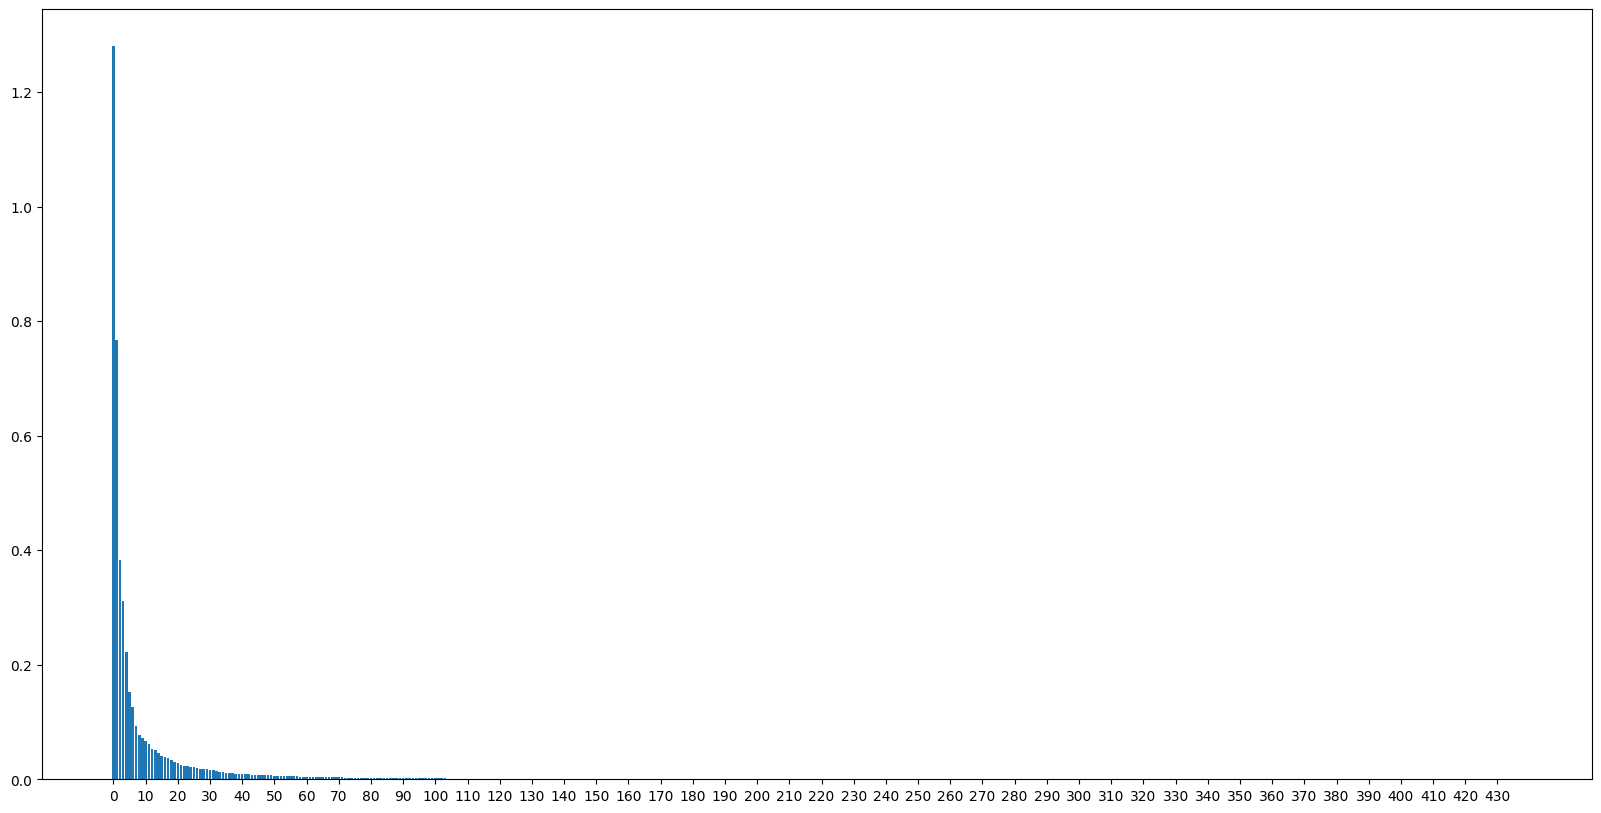

In [193]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(df)
df_pca_all = pca.transform(df)
eigenvalues = pca.explained_variance_
plt.bar(np.arange(0,df.shape[1],1), eigenvalues)
# make it more granular on the x axis - display every 10 values
plt.xticks(np.arange(0,df.shape[1],10))
# make the plot wider
plt.gcf().set_size_inches(20, 10)
# plt.plot(eigenvalues, "r")
# plt.plot(eigenvalues, "ro")
plt.show()

In [ ]:
from collections import defaultdict
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from collections import Counter
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import Birch
from sklearn.cluster import MiniBatchKMeans

class PFA(object):
    def __init__(self, n_features, q=None):
        self.q = q
        self.n_features = n_features
    def fit(self, X):
            if not self.q:
                self.q = X.shape[1]
            X = np.array(X)
            sc = StandardScaler()
        # X = sc.fit_transform(X)
            pca = PCA(n_components=self.q).fit(X) # calculation Cov matrix is embeded in PCA
            A_q = pca.components_.T
            kmeans = KMeans(n_clusters=self.n_features).fit(A_q)
            clusters = kmeans.predict(A_q)
            cluster_centers = kmeans.cluster_centers_
            dists = defaultdict(list)
            for i, c in enumerate(clusters):
                dist = euclidean_distances([A_q[i, :]], [cluster_centers[c, :]])[0][0]
                dists[c].append((i, dist))
            self.indices_ = [sorted(f, key=lambda x: x[1])[0][0] for f in dists.values()]
            self.features_ = X[:, self.indices_]
#Run exhaustive search to find the best features to keep:
def get_key(val,y):
    for key, value in Counter(y).items():
         if val == value:
             return key
 
    return "key doesn't exist"
p = 17
#n will be the number of features you have
n = 438
for k in range(2,n,1):
    print('########## K = ',k,' #######')
    pfa = PFA(n_features=k)
    pfa.fit(df)
    # To get the transformed matrix
    x = pfa.features_
    rng = np.random.RandomState(42)
    clf = IsolationForest(n_estimators=1000, random_state=rng)
    clf.fit(x)
    IF_labels = clf.predict(x)
    m = get_key(max(Counter(IF_labels).values()),IF_labels)
    x = pd.DataFrame(x)
    x['outliers'] = IF_labels
    x = x[x['outliers'] == m ]
    x = x.drop(columns = 'outliers')
    x = np.array(x)
    pca.fit(x)
    x = pca.transform(x)
    model_agg_clustering = AgglomerativeClustering(n_clusters=3)
    # fit model and predict clusters
    yhat_agg_clustering = model_agg_clustering.fit_predict(x)
    print('agglomerative')
    model_birch = Birch(threshold=0.01, n_clusters=3)
    # fit the model
    model_birch.fit(x)
    # assign a cluster to each example
    yhat_birch = model_birch.predict(x)
    model_mb_km = MiniBatchKMeans(n_clusters=3)
    # fit the model
    model_mb_km.fit(x)
    # assign a cluster to each example
    print('Mini Batch Kmeans')
    yhat_mb_km = model_mb_km.predict(x)
    label_list = [yhat_agg_clustering, yhat_birch, yhat_mb_km]
    models = ['AgglomerativeClustering', 'BIRCH', 'MiniBatch_KMeans']
    for idx,labels in enumerate(label_list):
        silhouette_avg = silhouette_score(x, labels)
        print("The average silhouette_score for", models[idx], " is :", silhouette_avg)

########## K =  2  #######


/opt/homebrew/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



agglomerative
Mini Batch Kmeans
The average silhouette_score for AgglomerativeClustering  is : 0.9988076774440997


/opt/homebrew/lib/python3.11/site-packages/sklearn/cluster/_birch.py:725: ConvergenceWarning:

Number of subclusters found (1) by BIRCH is less than (3). Decrease the threshold.

/opt/homebrew/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning:

The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

In [183]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Sun Sep 24 22:24:21 2023

@author: gabriel
"""

import numpy as np

import pandas as pd
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

from sklearn.datasets import make_classification


class FeatureSelector:
    def __init__(self, dataframe):
        self.df = dataframe

    def calculate_iterations(
        self, n_features, base_iterations=100, multiplier=50
    ):
        """
        Calculate the number of iterations based on the number of features.
        """
        n_iterations = base_iterations + multiplier * np.log(n_features)
        return int(n_iterations)

    def tree_based_feature_importance(self, n_select_features, rf_params=None):
        """
        Unsupervised Feature Selection with Random Forests (UFSRF)
        """
        # Number of features to select
        n_features = n_select_features

        # Calculate the number of iterations based on the total features
        n_iterations = self.calculate_iterations(self.df.shape[1])

        # Placeholder for feature importances across all iterations
        aggregated_importances = np.zeros(self.df.shape[1])

        # Ensure all data is float type
        df_float = self.df.astype(float)

        # Setting default RandomForest parameters if none provided
        if rf_params is None:
            rf_params = {
                "n_estimators": 150,
                "max_depth": 10,
                "random_state": 42,
            }

        for _ in range(n_iterations):
            # Generating random discrete class labels for classification
            random_labels = np.random.randint(0, 2, df_float.shape[0])
            model = RandomForestClassifier(**rf_params)
            model.fit(df_float, random_labels)
            aggregated_importances += model.feature_importances_

        # Averaging feature importances over all iterations
        aggregated_importances /= n_iterations

        # Sorting features based on their aggregated importance scores
        important_features = df_float.columns[
            np.argsort(aggregated_importances)[-n_features:]
        ]

        return df_float[important_features]




In [203]:
selector = FeatureSelector(df)
selected_features_df = selector.tree_based_feature_importance(
        n_select_features=100
    )

In [204]:
selected_features_df

,node:X:next:upos=PROPN,node:X:child:rel_shallow=amod,node:X:prev:Definite=Ind,node:X:parent:Subject=Generic,node:X:child:PronType=Dem,node:X:next:Definite=Def,node:X:own:rel_shallow=nsubj,node:X:next:PronType=Art,node:X:own:rel_shallow=obj,node:X:child:upos=PRON,...,node:X:parent:Tense=Past,node:X:next:Number=Sing,node:X:parent:upos=NOUN,node:X:next:upos=PUNCT,node:X:prev:Number=Sing,node:X:next:upos=ADP,node:X:parent:Number=Plur,node:X:parent:Number=Sing,node:X:parent:Gender=Fem,node:X:parent:Gender=Masc
"($, NOUN)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.076923,0.000000,...,0.076923,0.000000,0.461538,0.384615,0.000000,0.461538,0.230769,0.615385,0.230769,0.307692
"(%, NOUN)",0.000000,0.013605,0.000000,0.003401,0.010204,0.003401,0.108844,0.003401,0.159864,0.034014,...,0.142857,0.027211,0.323129,0.255102,0.017007,0.625850,0.336735,0.517007,0.204082,0.323129
"(&, CCONJ)",0.571429,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.142857,0.190476,0.000000,0.238095,0.047619,0.047619,0.142857,0.047619,0.142857
"(/, ADP)",0.047619,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.619048,0.571429,0.000000,0.428571,0.000000,0.333333,0.619048,0.095238,0.476190
"(/, CCONJ)",0.191919,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.020202,0.282828,0.303030,0.000000,0.282828,0.010101,0.262626,0.303030,0.090909,0.252525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(œil, NOUN)",0.000000,0.181818,0.090909,0.030303,0.000000,0.060606,0.121212,0.060606,0.181818,0.000000,...,0.181818,0.181818,0.303030,0.181818,0.242424,0.242424,0.272727,0.636364,0.090909,0.454545
"(œuf, NOUN)",0.000000,0.210526,0.157895,0.105263,0.052632,0.000000,0.000000,0.000000,0.368421,0.000000,...,0.105263,0.263158,0.526316,0.421053,0.210526,0.105263,0.368421,0.473684,0.210526,0.421053
"(œuvre, NOUN)",0.008696,0.226087,0.121739,0.008696,0.043478,0.017391,0.104348,0.034783,0.173913,0.043478,...,0.191304,0.191304,0.356522,0.182609,0.426087,0.365217,0.104348,0.739130,0.321739,0.243478
"(œuvrer, VERB)",0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,...,0.083333,0.000000,0.416667,0.000000,0.250000,1.000000,0.000000,0.666667,0.250000,0.250000


In [205]:
selected_features_df.columns

Index(['node:X:next:upos=PROPN', 'node:X:child:rel_shallow=amod',
       'node:X:prev:Definite=Ind', 'node:X:parent:Subject=Generic',
       'node:X:child:PronType=Dem', 'node:X:next:Definite=Def',
       'node:X:own:rel_shallow=nsubj', 'node:X:next:PronType=Art',
       'node:X:own:rel_shallow=obj', 'node:X:child:upos=PRON',
       'node:X:child:upos=AUX', 'node:X:parent:Tense=Imp',
       'node:X:next:upos=DET', 'node:X:child:rel_shallow=nsubj',
       'node:X:child:Voice=Pass', 'node:X:child:upos=DET',
       'node:X:next:upos=AUX', 'node:X:prev:PronType=Prs',
       'node:X:own:rel_shallow=root', 'node:X:prev:upos=DET',
       'node:X:prev:PronType=Art', 'node:X:next:upos=PRON',
       'node:X:child:PronType=Art', 'node:X:child:PronType=Prs',
       'node:X:prev:upos=CCONJ', 'node:X:prev:Definite=Def',
       'node:X:child:Definite=Def', 'node:X:own:rel_shallow=obl:mod',
       'node:X:parent:upos=PROPN', 'node:X:child:upos=NUM',
       'node:X:own:rel_shallow=obl:arg', 'node:X:nex

In [206]:
# make np array from the selected features
X_100_selected_features = np.array(selected_features_df)
clf = LocalOutlierFactor(n_neighbors=2, contamination=0.1)
clf.fit(X_100_selected_features)

# Predict outliers 
y_pred = clf.fit_predict(X_100_selected_features)
n_outliers = np.sum(y_pred == -1)

In [207]:
# Dimensionality reduction using t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_reduced = tsne.fit_transform(X_100_selected_features)

# Prepare data for Plotly visualization
data = pd.DataFrame({
    "Component 1": X_reduced[:, 0],
    "Component 2": X_reduced[:, 1],
    "Word": unique_lemma,
    "Outlier": ["Outlier" if pred == -1 else "Inlier" for pred in y_pred],
})

# Create a scatter plot with Plotly
fig = go.Figure()

# Add scatter points
fig.add_trace(go.Scatter(
    x=data["Component 1"],
    y=data["Component 2"],
    mode='markers',
    marker=dict(size=10, color=["red" if o == "Outlier" else "blue" for o in data["Outlier"]]),
    text=data["Word"],  
    customdata=data["Outlier"],  # Inlier/Outlier status for hover
    hovertemplate="Word: %{text}<br>Status: %{customdata}<extra></extra>"
))

# Update layout
fig.update_layout(
    title="t-SNE Visualization of all lemmas with LOF Outlier Detection",
    xaxis_title="t-SNE Component 1",
    yaxis_title="t-SNE Component 2",
    width=800,
    height=600
)

# Show the plot
fig.show()

print(f"Number of outliers detected: {n_outliers}/{X.shape[0]}")

Number of outliers detected: 293/2930


In [208]:
fig.write_html("lof_outliers_fr_ud_100_selected_features.html")

In [209]:
selector = FeatureSelector(df)
selected_features_df = selector.tree_based_feature_importance(
        n_select_features=10
    )

In [210]:
selected_features_df

,node:X:prev:Number=Plur,node:X:next:Number=Sing,node:X:parent:upos=NOUN,node:X:next:upos=PUNCT,node:X:parent:Number=Plur,node:X:prev:Number=Sing,node:X:next:upos=ADP,node:X:parent:Number=Sing,node:X:parent:Gender=Fem,node:X:parent:Gender=Masc
"($, NOUN)",0.923077,0.000000,0.461538,0.384615,0.230769,0.000000,0.461538,0.615385,0.230769,0.307692
"(%, NOUN)",0.982993,0.027211,0.323129,0.255102,0.336735,0.017007,0.625850,0.517007,0.204082,0.323129
"(&, CCONJ)",0.000000,0.142857,0.190476,0.000000,0.047619,0.238095,0.047619,0.142857,0.047619,0.142857
"(/, ADP)",0.523810,0.619048,0.571429,0.000000,0.333333,0.428571,0.000000,0.619048,0.095238,0.476190
"(/, CCONJ)",0.282828,0.282828,0.303030,0.000000,0.262626,0.282828,0.010101,0.303030,0.090909,0.252525
...,...,...,...,...,...,...,...,...,...,...
"(œil, NOUN)",0.757576,0.181818,0.303030,0.181818,0.272727,0.242424,0.242424,0.636364,0.090909,0.454545
"(œuf, NOUN)",0.631579,0.263158,0.526316,0.421053,0.368421,0.210526,0.105263,0.473684,0.210526,0.421053
"(œuvre, NOUN)",0.269565,0.191304,0.356522,0.182609,0.104348,0.426087,0.365217,0.739130,0.321739,0.243478
"(œuvrer, VERB)",0.000000,0.000000,0.416667,0.000000,0.000000,0.250000,1.000000,0.666667,0.250000,0.250000


In [211]:
selected_features_df.columns

Index(['node:X:prev:Number=Plur', 'node:X:next:Number=Sing',
       'node:X:parent:upos=NOUN', 'node:X:next:upos=PUNCT',
       'node:X:parent:Number=Plur', 'node:X:prev:Number=Sing',
       'node:X:next:upos=ADP', 'node:X:parent:Number=Sing',
       'node:X:parent:Gender=Fem', 'node:X:parent:Gender=Masc'],
      dtype='object')

In [212]:
# make np array from the selected features
X_10_selected_features = np.array(selected_features_df)
clf = LocalOutlierFactor(n_neighbors=2, contamination=0.1)
clf.fit(X_10_selected_features)

# Predict outliers 
y_pred = clf.fit_predict(X_10_selected_features)
n_outliers = np.sum(y_pred == -1)

In [213]:
# Dimensionality reduction using t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_reduced = tsne.fit_transform(X_10_selected_features)

# Prepare data for Plotly visualization
data = pd.DataFrame({
    "Component 1": X_reduced[:, 0],
    "Component 2": X_reduced[:, 1],
    "Word": unique_lemma,
    "Outlier": ["Outlier" if pred == -1 else "Inlier" for pred in y_pred],
})

# Create a scatter plot with Plotly
fig = go.Figure()

# Add scatter points
fig.add_trace(go.Scatter(
    x=data["Component 1"],
    y=data["Component 2"],
    mode='markers',
    marker=dict(size=10, color=["red" if o == "Outlier" else "blue" for o in data["Outlier"]]),
    text=data["Word"],  
    customdata=data["Outlier"],  # Inlier/Outlier status for hover
    hovertemplate="Word: %{text}<br>Status: %{customdata}<extra></extra>"
))

# Update layout
fig.update_layout(
    title="t-SNE Visualization of all lemmas with LOF Outlier Detection",
    xaxis_title="t-SNE Component 1",
    yaxis_title="t-SNE Component 2",
    width=800,
    height=600
)

# Show the plot
fig.show()

print(f"Number of outliers detected: {n_outliers}/{X.shape[0]}")

Number of outliers detected: 293/2930


In [214]:
fig.write_html("lof_outliers_fr_ud_10_selected_features.html")